In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

/tmp/ipykernel_6139/2956514991.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='viridis')


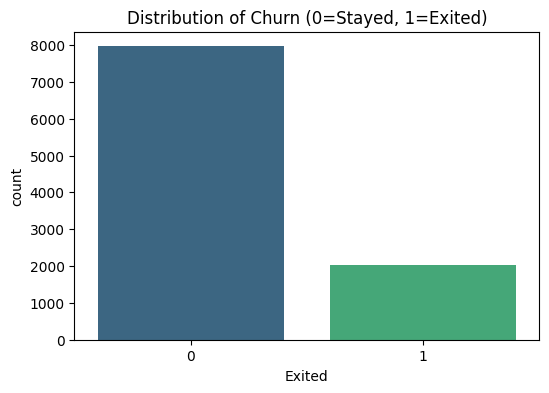

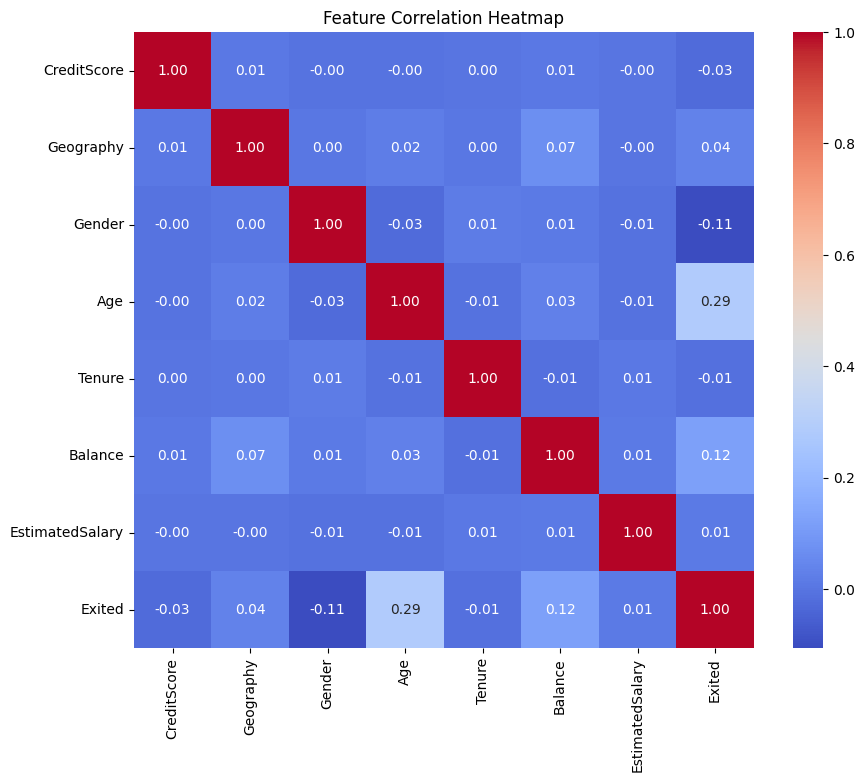

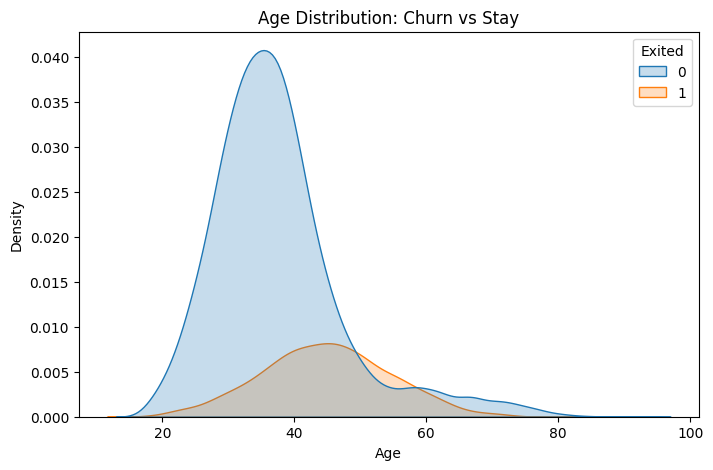

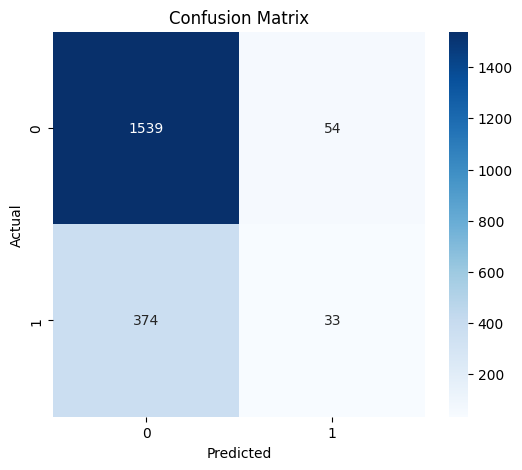

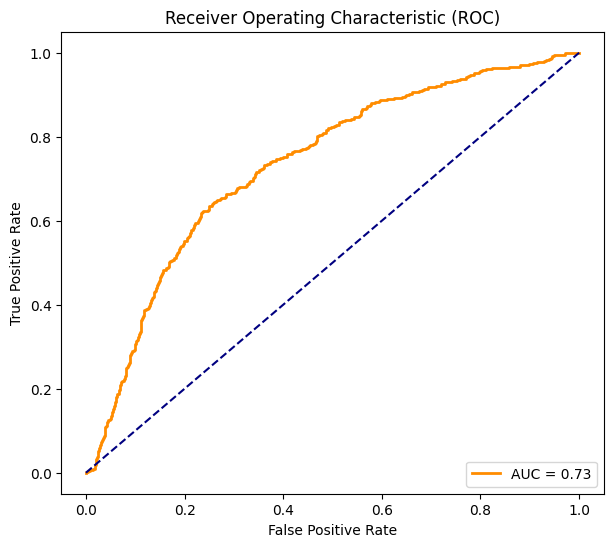

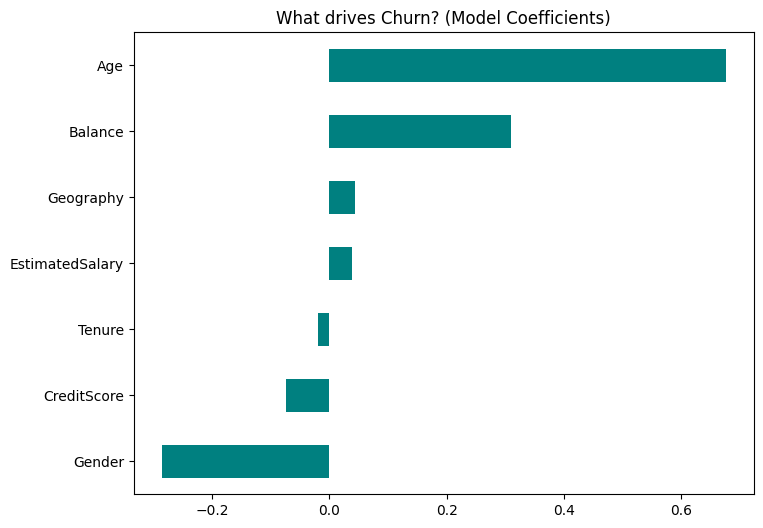

In [11]:


# ---------------------------------------------------------
# 1. LOAD & CLEAN DATA
# ---------------------------------------------------------
df = pd.read_csv("Customer Churn new.csv")

# Identify and remove identifiers (noise)
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical text into numbers
le = LabelEncoder()
df_clean['Geography'] = le.fit_transform(df_clean['Geography'])
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

# Define Features (X) and Target (y)
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# ---------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA) PLOTS
# ---------------------------------------------------------
# Plot A: Is the dataset balanced?
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Distribution of Churn (0=Stayed, 1=Exited)')
plt.show()

# Plot B: Which variables move together? (Correlation Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Plot C: Does Age impact Churn? (Distribution Plot)
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Age', hue='Exited', fill=True)
plt.title('Age Distribution: Churn vs Stay')
plt.show()

# ---------------------------------------------------------
# 3. TRAINING THE DATASET
# ---------------------------------------------------------
# Split: 80% for learning, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling: Logistic Regression needs features on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and Fit the model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# ---------------------------------------------------------
# 4. MODEL EVALUATION VISUALIZATIONS
# ---------------------------------------------------------
# Plot D: Confusion Matrix (Check errors)
y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Plot E: ROC Curve (Measures model quality across all thresholds)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Plot F: Feature Importance (Which variables matter most?)
coefficients = model.coef_[0]
feat_importances = pd.Series(coefficients, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
feat_importances.plot(kind='barh', color='teal')
plt.title('What drives Churn? (Model Coefficients)')
plt.show()